### In the previous chapter we learnt basic work flow of Machine Learning using regression problem

## Chapter 3 is all about classification using MNIST dataset.
#### - Binary classification
#### - Multiclass classification
#### - MultiOutput classification

### along with these we will also see some important techniques such as
#### - Performance Measures
#### - Confusion matrix (precision , recall , precision-recall tradeoff)
#### - ROC corve (Receiver operating Characteristic)
#### - Error analysis

## sample look of the dataset
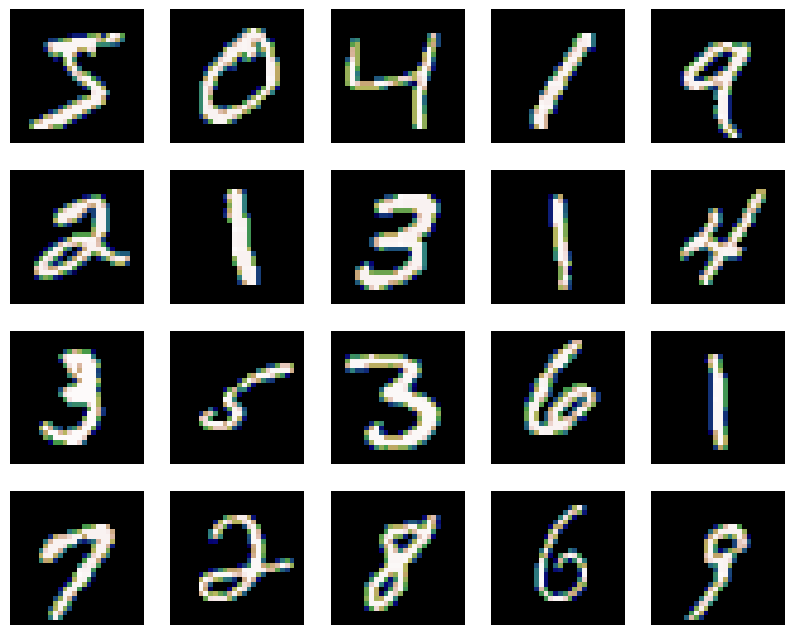

In [2]:
# Lets start by loading the MNIST dataset of images

from sklearn.datasets import fetch_openml

# as_frame = false because the fetch_openml returns a dataframe , but we are loading images which will be in the form of matrix.

mnist = fetch_openml('mnist_784' , as_frame=False) 

In [3]:
X , y = mnist.data , mnist.target

In [4]:
X.shape

(70000, 784)

In [5]:
y.shape

(70000,)

 - so there are 70000 images each 28*28 pixels = 784

In [6]:
print(type(X) , type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [7]:
import matplotlib.pyplot as plt

def plot_digits(digit_images):
    fig, axs = plt.subplots(4, 5, figsize=(10, 8))
    for i in range(20):
        axs[i//5, i%5].imshow(digit_images[i].reshape(28, 28), cmap="gist_earth")
        axs[i//5, i%5].axis("off")
    plt.show()

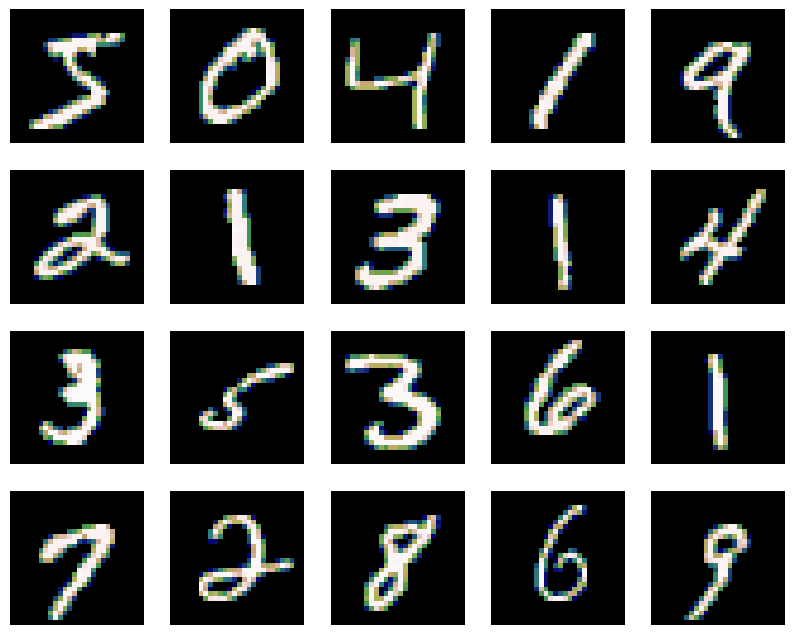

In [8]:
plot_digits(X[:20])

#### note since the fetch_openml returns the dataset that is well shuffled , we can directly go forward with splitting 

In [9]:
X_train , X_test , y_train , y_test = X[:60000] , X[60000:] , y[:60000] , y[60000:]

In [10]:
print(X_train.shape , y_train.shape , '\n' , X_test.shape , y_test.shape)

(60000, 784) (60000,) 
 (10000, 784) (10000,)


#### now the split dataset is ready , lets train a Binary classifier
- the dataset has 10 classes

In [11]:
# we can see there are 10 digits from 0-9
set(y)

{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'}

In [12]:
# for binary classifier we need to set a number as true and the rest as false

y_train_4 = (y_train == '4')
y_test_4  = (y_test == '4')

In [13]:
set(y_train_4)

{False, True}

## lets try SGDClassifier Stochastic gradient descent classifier

In [15]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix , precision_score , recall_score , f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [14]:
sgd_class = SGDClassifier(loss="squared_error",penalty="elasticnet" , learning_rate="adaptive" ,eta0=0.01 , random_state=42)

In [15]:
sgd_class.fit(X_train , y_train_4)

SGDClassifier(eta0=0.01, learning_rate='adaptive', loss='squared_error',
              penalty='elasticnet', random_state=42)

#### now lets meaure the classifier performance .
### - different Performance measures for classification are . 
- Measuring accuracy using cross validation
- Confusion matrix
- precision , recall , precision-recall tradeoff
- ROC vurve 

In [16]:
# Measuring accuracy using cross validation

from sklearn.model_selection import cross_val_score

cross_val_score(sgd_class , X_train , y=y_train_4 , scoring="accuracy" , cv=10 )

array([0.69566667, 0.49916667, 0.537     , 0.18116667, 0.2195    ,
       0.28566667, 0.80983333, 0.58033333, 0.17833333, 0.40883333])

- lets test with a dummy classifier

In [17]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train , y_train_4)

DummyClassifier()

In [18]:
cross_val_score(dummy_clf , X_train , y=y_train_4 , scoring="accuracy" , cv=10 )

array([0.90266667, 0.90266667, 0.90266667, 0.90266667, 0.90266667,
       0.90266667, 0.90266667, 0.90266667, 0.9025    , 0.9025    ])

- we can observe that the dummy classifier is giving more accuracy than SGD classifier
    - the reason is 90% of the data is false , and only 10% is true for digit 4. there is data imbalance
    - randomly guessing the digit we can tell false , which will be correct ofr 90% of the times.
#### - outcome learning 
        - "ACCURACY" is not the best performance measure for classification with **imbalanced data**

---------------------------------------------------
## - Confusion Matrix

In [19]:
y_train_pred = cross_val_predict(sgd_class , X=X_train , y=y_train_4 , cv = 3)

cm = confusion_matrix(y_true=y_train_4,y_pred=y_train_pred)
cm

array([[28192, 25966],
       [ 1895,  3947]])

 - TN = 28192
 - TP = 3947
 - FP = 25966
 - FN = 1895
 

- lets see what is precision , recall , F1-score
    - precision = TP / (TP + FN) =  3947 / (3947 + 25966) = 0.13194932 
    - recall    = TP / (TP + FP) =  3947 / (3947 + 1895) = 0.675624786 
    - F1-score  = 2 * (precision * recall) / (precsion + recall) = 2 * (0.1319 × 0.6756)÷ (0.1319 + 0.6756) = 0.220709944 

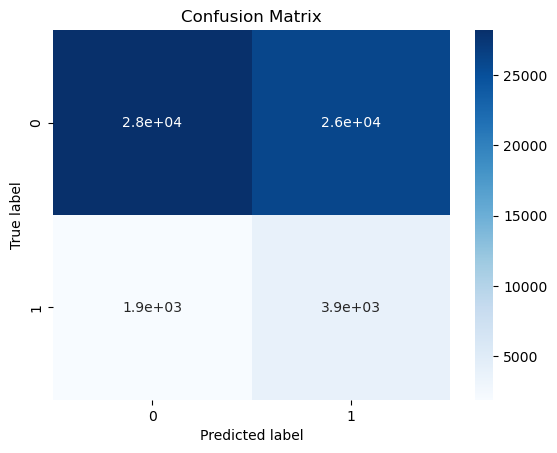

In [30]:
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

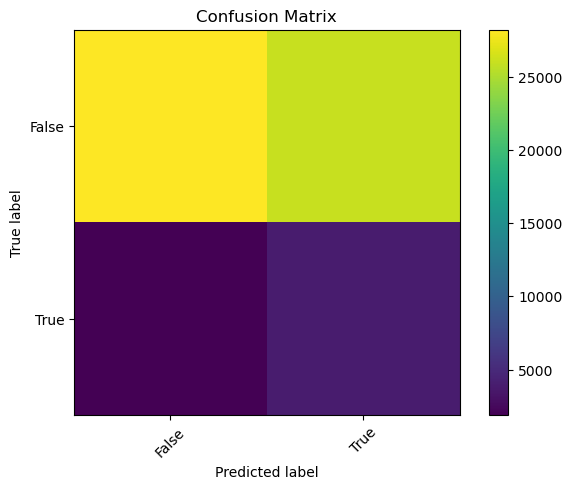

In [31]:
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(set(y_train_4)))
plt.xticks(tick_marks, set(y_train_4), rotation=45)
plt.yticks(tick_marks, set(y_train_4))
plt.tight_layout()
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()

In [20]:
# LETS CHECK  

precision_score(y_true=y_train_4 , y_pred=y_train_pred)

0.13194931969377863

In [21]:
recall_score(y_true=y_train_4 , y_pred=y_train_pred)

0.6756247860321808

In [22]:
f1_score(y_true=y_train_4 , y_pred=y_train_pred)

0.22078031044609145

- depending on the problem statement we want a trade off between precision and recall
    - for example a doctor using a model for fever (yes / no ) prediction should have higher precison , i.e TP should be higher and FP should be lesser
    - recall should be higher : when the model is trying to alarm the bank gaurds upon suspecting the robbery using CCTV imaging 

## the classifiers don't directly predict the class , they estimate a score and the threshold this threshold determines which score should be classified to what 


In [16]:
sgd_class = SGDClassifier(random_state=42)
sgd_class.fit(X_train , y_train_4)

SGDClassifier(random_state=42)

In [17]:
y4_scores_sgd = cross_val_predict(sgd_class , X = X_train ,y= y_train_4 , cv = 3 , method="decision_function" )
y4_scores_sgd

array([-31754.76525516, -26393.82888302,   2160.11030898, ...,
       -19439.69962707, -10979.35873154, -22487.33775957])

In [18]:
from sklearn.metrics import precision_recall_curve , auc , roc_curve
precisions , recalls , thresholds = precision_recall_curve(y_train_4 , y4_scores_sgd)
precisions

array([0.09736667, 0.09736829, 0.09736991, ..., 1.        , 1.        ,
       1.        ])

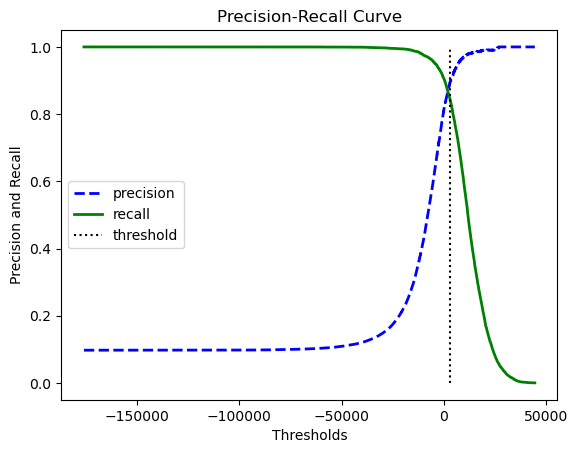

In [51]:
plt.plot(thresholds, precisions[:-1], "b--", label="precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="recall", linewidth=2)
plt.vlines(3000, 0, 1.0, "k", "dotted")
plt.plot([], [], "k:", label="threshold")
plt.legend(loc = "best")
plt.xlabel("Thresholds")
plt.ylabel("Precision and Recall")
plt.title("Precision-Recall Curve")
plt.show()

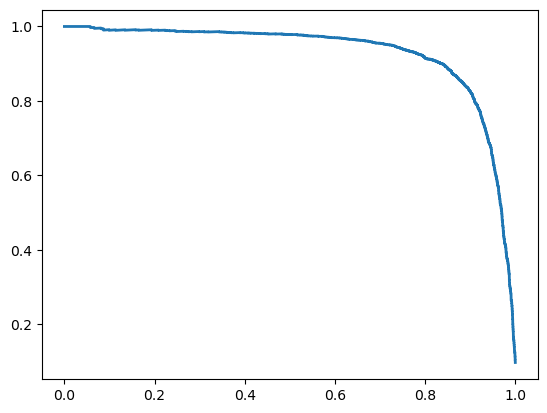

In [27]:
plt.plot(recalls , precisions , linewidth = 2 , label = "precision/recall curve")
plt.show()

# - ROC curve
    - a good classifier should have AUC close to 1

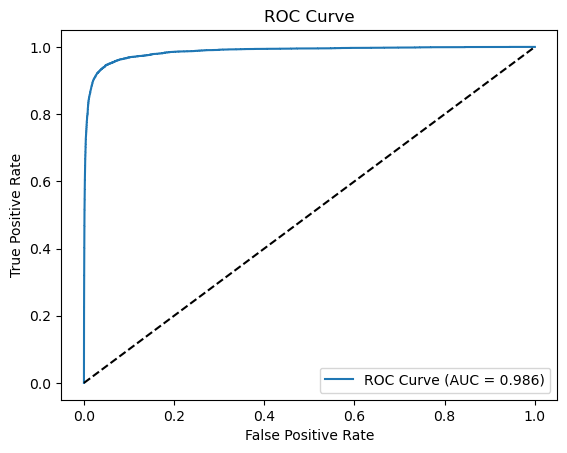

In [28]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_train_4, y4_scores_sgd)

# Calculate the AUC
auc_value = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.3f})'.format(auc_value))
plt.plot([0, 1], [0, 1], 'k--')  # plot the diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## ROC curve and AUC are mainly used for comapring multiple classifers 
 - to understand this lets build a another classifier and see which gives better results 

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X=X_train , y=y_train_4)

RandomForestClassifier(random_state=42)

In [20]:
y4_scores_rf = cross_val_predict(rf_clf , X = X_train ,y= y_train_4 , cv = 3 , method='predict_proba')
y4_scores_rf

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.26, 0.74],
       ...,
       [0.99, 0.01],
       [0.97, 0.03],
       [0.98, 0.02]])

In [21]:
precisions_rf , recalls_rf , thresholds_rf = precision_recall_curve(y_true=y_train_4 , y_score=y4_scores_rf[:,1])


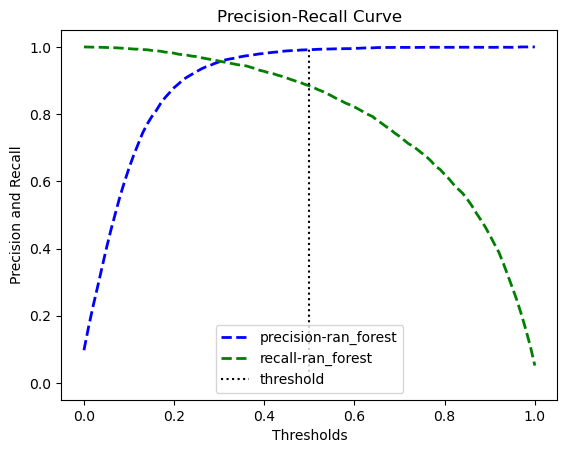

In [23]:
plt.plot(thresholds_rf, precisions_rf[:-1], "b--", label="precision-ran_forest", linewidth=2)
plt.plot(thresholds_rf, recalls_rf[:-1], "g--", label="recall-ran_forest", linewidth=2)
plt.vlines(0.5 ,0, 1.0, "k", "dotted")
plt.plot([], [], "k:", label="threshold")
plt.legend(loc = "best")
plt.xlabel("Thresholds")
plt.ylabel("Precision and Recall")
plt.title("Precision-Recall Curve")
plt.show()

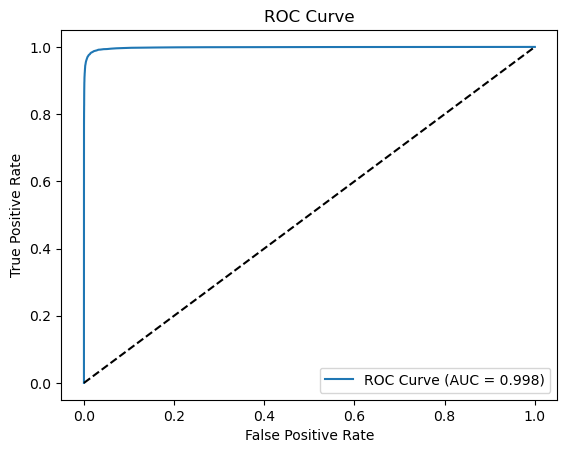

In [25]:
# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_train_4, y4_scores_rf[:,-1])

# Calculate the AUC
auc_value = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.3f})'.format(auc_value))
plt.plot([0, 1], [0, 1], 'k--')  # plot the diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# - Multiclass classification
    - we can use OneVsRestClassier
    - KneighborsClassifiers

## lets discuss this in the next practical notebook
